In [1]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_classic.schema import Document

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from langchain_classic.tools.retriever import create_retriever_tool

In [ ]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)
embedding = OpenAIEmbeddings()



In [ ]:
class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]
    
def make_retriever_tool_from_text(file_path, tool_name, desc):
    loader = PyMuPDFLoader(file_path=file_path)
    docs = loader.load()
    
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80)
    chunks = text_splitter.split_documents(docs)
    
    vectorstore = FAISS.from_documents(chunks, embedding)
    retriever = vectorstore.as_retriever()
    
    def tool_retriever():
        retriever_tool = create_retriever_tool(
            retriever,
            tool_name,
            desc
        )
    
        return retriever_tool
    
    retriever_tool = tool_retriever()
    return retriever_tool



In [4]:
nilai_farhan_tool = make_retriever_tool_from_text(
    "pdf/farhan.pdf",
    "SikadFarhan",
    "Mencari informasi nilai untuk mahasiswa farhan dan IPK farhan atau hasil akhir perkuliahan farhan"
)

nilai_ratu_tool = make_retriever_tool_from_text(
    "pdf/ratu.pdf",
    "SikadRatu",
    "Mencari informasi nilai untuk mahasiswa Ratu dan IPK Ratu atau hasil akhir perkuliahan Ratu"
)

tools = [nilai_farhan_tool, nilai_ratu_tool]

In [5]:
llm_with_tools = model.bind_tools(tools)

In [6]:


def tool_calling_llm(state:State) -> State:
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

In [11]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_classic import hub
from pydantic import BaseModel, Field


def grade_document(state:State) -> Literal["generate", "rewrite"]:
    
   class grade(BaseModel):
      """Binary score for relevance check."""

      binary_score: str = Field(description="Relevance score 'yes' or 'no'")
        
   model = ChatGroq(model_name="openai/gpt-oss-120b",  streaming=True)
   llm_with_tools = model.with_structured_output(grade)
   
   prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )
   
   chain = prompt | llm_with_tools
   
   last_message = state["messages"][-1]
   
   question = state["messages"][0].content
   docs = last_message.content
   
   
   scored_result = chain.invoke({"question": question, "context": docs})

   score = scored_result.binary_score

   if score == "yes":
      print("---DECISION: DOCS RELEVANT---")
      return "generate"

   else:
      print("---DECISION: DOCS NOT RELEVANT---")
      print(score)
      return "rewrite"

In [25]:
def generate(state:State):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = next(
        (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)),
        None
    )
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model_name="openai/gpt-oss-120b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [26]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = next(
        (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)),
        None
    )

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model_name="openai/gpt-oss-120b")
    response = model.invoke(msg)
    return {"messages": [response]}

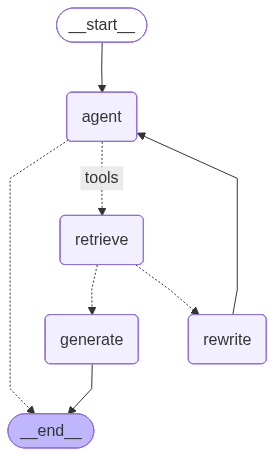

In [ ]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(State)

workflow.add_node("agent", tool_calling_llm)
retrieve = ToolNode([nilai_farhan_tool, nilai_ratu_tool])
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node(
    "generate", generate
) 
workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    grade_document,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [30]:
def make_config(thread_id):
    return {"configurable" : {"thread_id" : thread_id}}

config = make_config(1)

response = graph.invoke({"messages":"Nama saya Farhan"}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Nama saya Farhan
================================== Ai Message ==================================

Hai Farhan! Senang bertemu dengan Anda. Ada yang bisa saya bantu terkait data akademik Anda, seperti nilai mata kuliah, IPK, atau informasi lain? Silakan beri tahu saya apa yang Anda perlukan.


In [33]:

response = graph.invoke({"messages":"berapa nilai saya"}, config=config)

for msg in response["messages"]:
    msg.pretty_print()

---DECISION: DOCS RELEVANT---
---GENERATE---
================================ Human Message =================================

Nama saya Farhan
================================== Ai Message ==================================

Hai Farhan! Senang bertemu dengan Anda. Ada yang bisa saya bantu terkait data akademik Anda, seperti nilai mata kuliah, IPK, atau informasi lain? Silakan beri tahu saya apa yang Anda perlukan.
================================ Human Message =================================

berapa nilai aku?
================================== Ai Message ==================================
Tool Calls:
  SikadFarhan (fc_556b79ea-28d9-49fe-9dd8-8289b767b12c)
 Call ID: fc_556b79ea-28d9-49fe-9dd8-8289b767b12c
  Args:
    query: nilai Farhan
================================ Human Message =================================

berapa nilai saya
================================== Ai Message ==================================
Tool Calls:
  SikadFarhan (fc_78745faf-7510-4ec5-a2ba-2d90580a7cd7)
 

In [34]:

response = graph.invoke({"messages":"temen saya ratu dan berapa nilai dia? "}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
================================ Human Message =================================

Nama saya Farhan
================================== Ai Message ==================================

Hai Farhan! Senang bertemu dengan Anda. Ada yang bisa saya bantu terkait data akademik Anda, seperti nilai mata kuliah, IPK, atau informasi lain? Silakan beri tahu saya apa yang Anda perlukan.
================================ Human Message =================================

berapa nilai aku?
================================== Ai Message ==================================
Tool Calls:
  SikadFarhan (fc_556b79ea-28d9-49fe-9dd8-8289b767b12c)
 Call ID: fc_556b79ea-28d9-49fe-9dd8-8289b767b12c
  Args:
    query: nilai Farhan
================================ Human Message =================================

berapa nilai saya
================================== Ai Message ==================================
Tool Calls:
  SikadFarhan (fc_78745faf-7510-4ec5-a2ba-2